In [1]:
# =========================================================
# Day 4. 지도학습 - 회귀 실습
# 실제 업로드 파일 기준: supervised_label_cn7.csv
# 회귀 타깃: Filling_Time
# =========================================================

In [2]:
# ---------------------------------------------------------
# 1. 라이브러리 불러오기
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
# ---------------------------------------------------------
# 2. 기본 설정
# ---------------------------------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [4]:
# 한글/그래프 기본 설정
import platform
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:                           # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

In [5]:
# ---------------------------------------------------------
# 3. 데이터 불러오기
# ---------------------------------------------------------
file_path = "supervised_label_cn7.csv"
df = pd.read_csv(file_path)

print("=== 원본 데이터 상위 5행 ===")
display(df.head())

=== 원본 데이터 상위 5행 ===


,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5


In [6]:
# ---------------------------------------------------------
# 4. 불필요 컬럼 제거
# ---------------------------------------------------------
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("=== 컬럼 정리 후 상위 5행 ===")
display(df.head())

=== 컬럼 정리 후 상위 5행 ===


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5


In [7]:
# ---------------------------------------------------------
# 5. 데이터 기본 확인
# ---------------------------------------------------------
print("=== 데이터 크기 ===")
print(df.shape)

=== 데이터 크기 ===
(6736, 25)


In [8]:
print("\n=== 데이터 정보 ===")
df.info()


=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                6736 non-null   int64  
 1   Injection_Time            6736 non-null   float64
 2   Filling_Time              6736 non-null   float64
 3   Plasticizing_Time         6736 non-null   float64
 4   Cycle_Time                6736 non-null   float64
 5   Clamp_Close_Time          6736 non-null   float64
 6   Cushion_Position          6736 non-null   float64
 7   Plasticizing_Position     6736 non-null   float64
 8   Clamp_Open_Position       6736 non-null   float64
 9   Max_Injection_Speed       6736 non-null   float64
 10  Max_Screw_RPM             6736 non-null   float64
 11  Average_Screw_RPM         6736 non-null   float64
 12  Max_Injection_Pressure    6736 non-null   float64
 13  Max_Switch_Over_Pressure  6736 non-null   float

In [9]:
print("\n=== 기초 통계량 ===")
display(df.describe().T)


=== 기초 통계량 ===


,count,mean,std,min,25%,50%,75%,max
PassOrFail,6736.0,0.005790,0.075876,0.000000,0.000000,0.000000,0.000000,1.000000
Injection_Time,6736.0,9.580064,0.180526,9.360000,9.530000,9.570000,9.600000,13.390000
Filling_Time,6736.0,4.448425,0.140286,3.350000,4.420000,4.450000,4.480000,8.270000
Plasticizing_Time,6736.0,16.820433,0.288946,16.469999,16.629999,16.820000,16.910000,21.100000
Cycle_Time,6736.0,59.549314,0.372267,58.840000,59.480000,59.520000,59.540001,64.349998
Clamp_Close_Time,6736.0,7.113639,0.075843,6.070000,7.120000,7.120000,7.120000,7.180000
Cushion_Position,6736.0,653.440859,0.115004,653.390015,653.429993,653.429993,653.440002,655.000000
Plasticizing_Position,6736.0,68.381941,0.648307,59.759998,68.320000,68.360001,68.510002,68.860001
Clamp_Open_Position,6736.0,644.899046,42.170577,69.639999,647.989990,647.989990,647.989990,647.989990
Max_Injection_Speed,6736.0,55.523085,1.005340,38.500000,55.099998,55.400002,55.900002,64.800003


In [10]:
# ---------------------------------------------------------
# 6. 회귀 타깃 설정
# ---------------------------------------------------------
# 회귀 예측 대상
target_col = "Filling_Time"

print("\n=== 회귀 타깃 ===")
print("target_col =", target_col)


=== 회귀 타깃 ===
target_col = Filling_Time


In [11]:
# ---------------------------------------------------------
# 7. 데이터(X) / 정답(y) 분리
#    - target 자체는 X에서 제거
#    - PassOrFail은 결과 라벨이므로 회귀 입력에서 제외
# ---------------------------------------------------------
drop_cols = [target_col, "PassOrFail"]
X = df.drop(columns=drop_cols)
y = df[target_col]

print("\n=== X, y 크기 ===")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\n=== 입력 변수 목록 ===")
print(X.columns.tolist())

print("\n=== y 기초 통계 ===")
display(y.describe())


=== X, y 크기 ===
X shape: (6736, 23)
y shape: (6736,)

=== 입력 변수 목록 ===
['Injection_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

=== y 기초 통계 ===


count    6736.000000
mean        4.448425
std         0.140286
min         3.350000
25%         4.420000
50%         4.450000
75%         4.480000
max         8.270000
Name: Filling_Time, dtype: float64

In [12]:
# ---------------------------------------------------------
# 8. train / test 분리
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\n=== train / test 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


=== train / test 크기 ===
X_train: (5388, 23)
X_test : (1348, 23)
y_train: (5388,)
y_test : (1348,)


In [13]:
# ---------------------------------------------------------
# 9. 회귀 평가 함수
# ---------------------------------------------------------
def print_regression_metrics(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {model_name} 성능 ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

In [14]:
# ---------------------------------------------------------
# 10. 상관이 큰 변수 확인
# ---------------------------------------------------------
corr_with_target = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)

print("\n=== Filling_Time과 상관이 큰 변수 상위 10개 ===")
display(corr_with_target.head(10))


=== Filling_Time과 상관이 큰 변수 상위 10개 ===


Max_Injection_Speed        -0.909069
Max_Switch_Over_Pressure    0.877999
Average_Back_Pressure       0.621711
Plasticizing_Position       0.588446
Max_Back_Pressure           0.577808
Clamp_Close_Time            0.570283
Clamp_Open_Position         0.568761
Barrel_Temperature_3        0.563295
Barrel_Temperature_2        0.560677
Barrel_Temperature_5        0.556129
Name: Filling_Time, dtype: float64

In [15]:
# ---------------------------------------------------------
# 11. 기준 모델 1: Linear Regression
# ---------------------------------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print_regression_metrics(y_test, y_pred_linear, "Linear Regression")


=== Linear Regression 성능 ===
MAE : 0.0048
RMSE: 0.0049
R²  : 0.9976


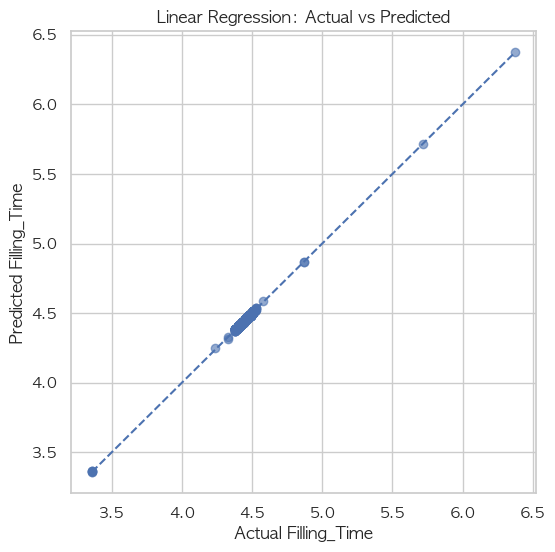

In [16]:
# ---------------------------------------------------------
# 12. 선형회귀 결과 시각화
# ---------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Filling_Time")
plt.ylabel("Predicted Filling_Time")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [17]:
# ---------------------------------------------------------
# 13. 선형회귀 계수 확인
# ---------------------------------------------------------
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linear_model.coef_
}).sort_values("coefficient", ascending=False)

print("\n=== 선형회귀 계수 ===")
display(coef_df)


=== 선형회귀 계수 ===


,feature,coefficient
0,Injection_Time,0.986438
3,Clamp_Close_Time,0.024235
4,Cushion_Position,0.005317
6,Clamp_Open_Position,0.005232
10,Max_Injection_Pressure,0.003188
1,Plasticizing_Time,0.002584
19,Barrel_Temperature_6,0.000857
22,Mold_Temperature_4,0.000836
13,Average_Back_Pressure,0.000514
8,Max_Screw_RPM,0.000469


In [18]:
# ---------------------------------------------------------
# 14. 기준 모델 2: Ridge
# ---------------------------------------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

print_regression_metrics(y_test, y_pred_ridge, "Ridge Regression")


=== Ridge Regression 성능 ===
MAE : 0.005
RMSE: 0.0072
R²  : 0.9948


In [19]:
# ---------------------------------------------------------
# 15. 비교 모델 3: Decision Tree Regressor
# ---------------------------------------------------------
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print_regression_metrics(y_test, y_pred_tree, "Decision Tree Regressor")


=== Decision Tree Regressor 성능 ===
MAE : 0.0002
RMSE: 0.0015
R²  : 0.9998


In [20]:
# ---------------------------------------------------------
# 16. 비교 모델 4: Random Forest Regressor
# ---------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print_regression_metrics(y_test, y_pred_rf, "Random Forest Regressor")


=== Random Forest Regressor 성능 ===
MAE : 0.001
RMSE: 0.0027
R²  : 0.9993


In [21]:
# ---------------------------------------------------------
# 17. 모델 성능 비교표
# ---------------------------------------------------------
compare_df = pd.DataFrame({
    "model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_linear) ** 0.5,
        mean_squared_error(y_test, y_pred_ridge) ** 0.5,
        mean_squared_error(y_test, y_pred_tree) ** 0.5,
        mean_squared_error(y_test, y_pred_rf) ** 0.5
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_rf)
    ]
})

print("\n=== 회귀 모델 비교표 ===")
display(compare_df.sort_values("RMSE"))


=== 회귀 모델 비교표 ===


,model,MAE,RMSE,R2
2,Decision Tree Regressor,0.000223,0.001492,0.999776
3,Random Forest Regressor,0.000965,0.002726,0.999252
0,Linear Regression,0.004842,0.004930,0.997553
1,Ridge Regression,0.005044,0.007213,0.994760


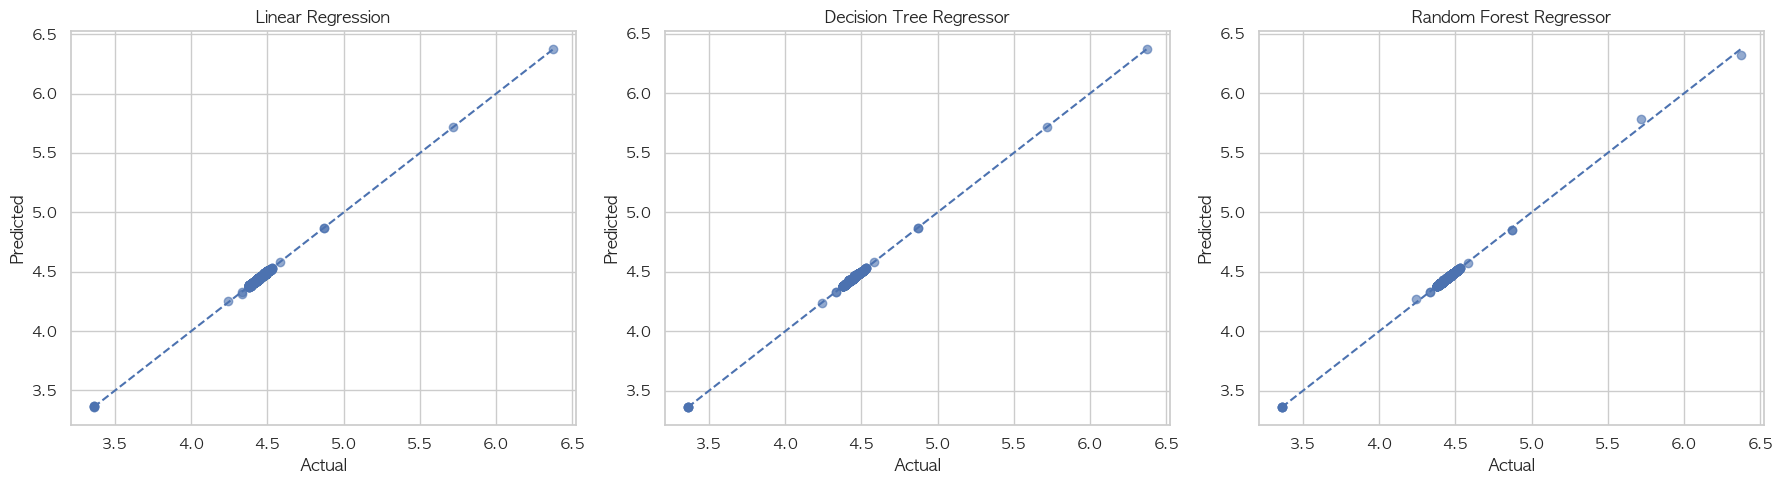

In [22]:
# ---------------------------------------------------------
# 18. 여러 모델 Actual vs Predicted 비교 시각화
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))

plt.subplot(131)
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(132)
plt.scatter(y_test, y_pred_tree, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Decision Tree Regressor")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(133)
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Random Forest Regressor")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

In [23]:
# ---------------------------------------------------------
# 19. 잔차(residual) 분석
# ---------------------------------------------------------
residual_df = pd.DataFrame({
    "actual": y_test.values,
    "pred_linear": y_pred_linear,
    "pred_rf": y_pred_rf
}, index=y_test.index)

residual_df["residual_linear"] = residual_df["actual"] - residual_df["pred_linear"]
residual_df["residual_rf"] = residual_df["actual"] - residual_df["pred_rf"]

print("\n=== 잔차 데이터 일부 ===")
display(residual_df.head())


=== 잔차 데이터 일부 ===


,actual,pred_linear,pred_rf,residual_linear,residual_rf
381,4.42,4.425144,4.421167,-0.005144,-1.166638e-03
2877,4.39,4.384286,4.390000,0.005713,4.440892e-15
5314,4.47,4.474351,4.470000,-0.004351,2.042810e-14
2018,4.48,4.484766,4.480467,-0.004766,-4.666551e-04
2185,4.51,4.504891,4.509134,0.005110,8.666865e-04


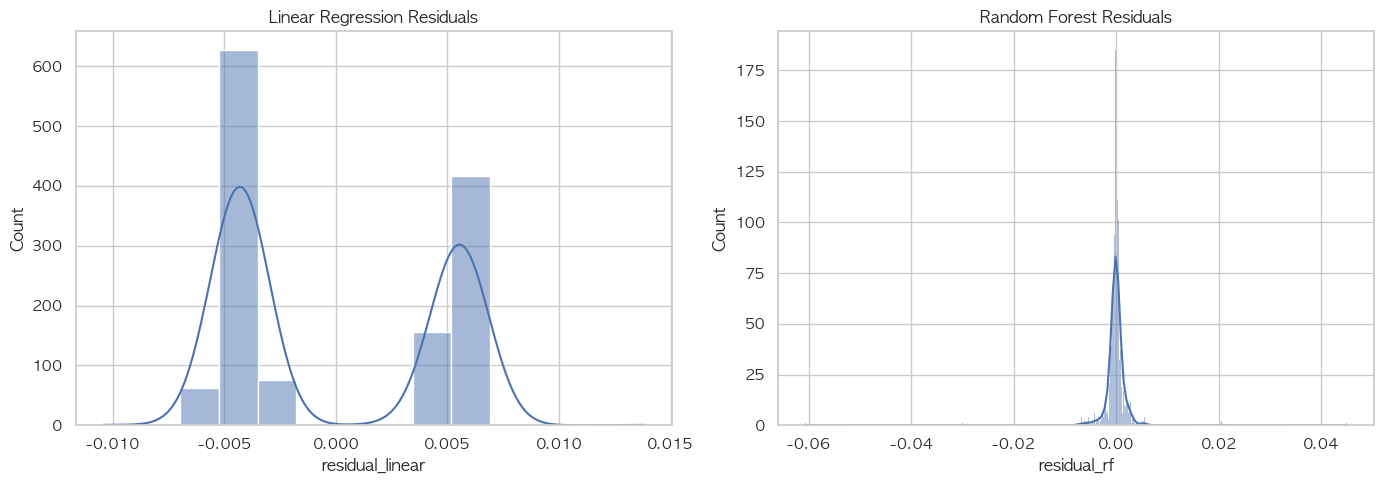

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(121)
sns.histplot(residual_df["residual_linear"], kde=True)
plt.title("Linear Regression Residuals")

plt.subplot(122)
sns.histplot(residual_df["residual_rf"], kde=True)
plt.title("Random Forest Residuals")

plt.tight_layout()
plt.show()

In [25]:
# ---------------------------------------------------------
# 20. 큰 오차 사례 확인
# ---------------------------------------------------------
error_df = pd.DataFrame({
    "actual": y_test.values,
    "pred_linear": y_pred_linear,
    "pred_rf": y_pred_rf
}, index=y_test.index)

error_df["abs_error_linear"] = (error_df["actual"] - error_df["pred_linear"]).abs()
error_df["abs_error_rf"] = (error_df["actual"] - error_df["pred_rf"]).abs()

print("\n=== 선형회귀 큰 오차 상위 10개 ===")
display(error_df.sort_values("abs_error_linear", ascending=False).head(10))

print("\n=== 랜덤포레스트 큰 오차 상위 10개 ===")
display(error_df.sort_values("abs_error_rf", ascending=False).head(10))


=== 선형회귀 큰 오차 상위 10개 ===


,actual,pred_linear,pred_rf,abs_error_linear,abs_error_rf
59,4.33,4.316161,4.329633,0.013839,0.000367
604,4.24,4.250432,4.270000,0.010432,0.030000
5736,3.36,3.367769,3.360033,0.007769,0.000033
2836,4.40,4.392920,4.399567,0.007080,0.000433
6207,4.40,4.392920,4.399567,0.007080,0.000433
5267,4.45,4.442929,4.449933,0.007071,0.000067
1876,4.49,4.483051,4.489733,0.006948,0.000267
5275,4.49,4.483128,4.489633,0.006872,0.000367
6415,4.45,4.443140,4.449966,0.006860,0.000033
3045,4.45,4.443140,4.449966,0.006860,0.000033



=== 랜덤포레스트 큰 오차 상위 10개 ===


,actual,pred_linear,pred_rf,abs_error_linear,abs_error_rf
2022,5.72,5.714786,5.780666,0.005214,0.060667
5391,6.37,6.373650,6.325000,0.003650,0.045000
604,4.24,4.250432,4.270000,0.010432,0.030000
2024,4.87,4.865621,4.849567,0.004379,0.020433
4010,4.87,4.865621,4.849567,0.004379,0.020433
3910,4.42,4.424644,4.427400,0.004644,0.007400
544,4.42,4.424644,4.427400,0.004644,0.007400
4393,4.45,4.453680,4.456833,0.003680,0.006833
5775,4.45,4.453680,4.456833,0.003680,0.006833
1027,4.45,4.453680,4.456833,0.003680,0.006833



=== Random Forest 중요 변수 ===


,feature,importance
7,Max_Injection_Speed,0.337873
0,Injection_Time,0.169396
11,Max_Switch_Over_Pressure,0.153688
10,Max_Injection_Pressure,0.031026
19,Barrel_Temperature_6,0.029677
4,Cushion_Position,0.028857
17,Barrel_Temperature_4,0.025870
12,Max_Back_Pressure,0.023397
13,Average_Back_Pressure,0.022012
14,Barrel_Temperature_1,0.021876


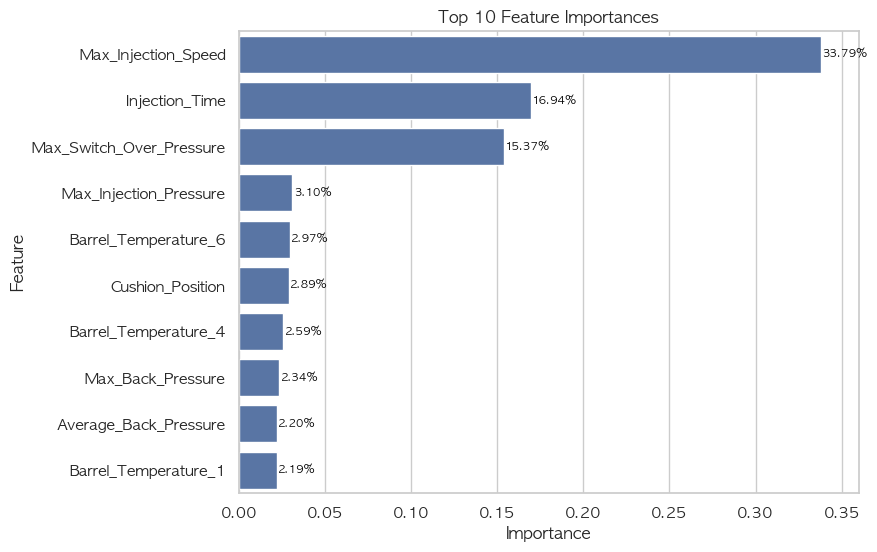

In [26]:
# ---------------------------------------------------------
# 21. Random Forest 중요 변수 확인
# ---------------------------------------------------------
rf_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== Random Forest 중요 변수 ===")
display(rf_importance_df)

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=rf_importance_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", padding=1, fontsize=8, color="black", fontweight="bold")
plt.xlim(0, 0.37)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [27]:
# ---------------------------------------------------------
# 22. 하이퍼파라미터 튜닝 - Random Forest
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n=== GridSearchCV 결과 ===")
print("Best Params:", grid.best_params_)
print("Best CV Score (negative RMSE):", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print_regression_metrics(y_test, y_pred_best_rf, "Tuned Random Forest Regressor")


=== GridSearchCV 결과 ===
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score (negative RMSE): -0.02058975121335132

=== Tuned Random Forest Regressor 성능 ===
MAE : 0.001
RMSE: 0.0027
R²  : 0.9993


In [28]:
# ---------------------------------------------------------
# 23. 튜닝 전후 비교
# ---------------------------------------------------------
tuned_compare_df = pd.DataFrame({
    "model": ["Random Forest", "Tuned Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_best_rf)
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_rf) ** 0.5,
        mean_squared_error(y_test, y_pred_best_rf) ** 0.5
    ],
    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_best_rf)
    ]
})

print("\n=== 튜닝 전후 비교 ===")
display(tuned_compare_df)


=== 튜닝 전후 비교 ===


,model,MAE,RMSE,R2
0,Random Forest,0.000965,0.002726,0.999252
1,Tuned Random Forest,0.000965,0.002726,0.999252


In [29]:
# ---------------------------------------------------------
# 24. 샘플 1건 예측
# ---------------------------------------------------------
sample_input = X_test.iloc[[0]].copy()

print("\n=== 샘플 입력 데이터 ===")
display(sample_input)

sample_pred_linear = linear_model.predict(sample_input)[0]
sample_pred_rf = rf_model.predict(sample_input)[0]
sample_pred_best_rf = best_rf.predict(sample_input)[0]
sample_actual = y_test.loc[sample_input.index].values[0]

print("\n=== 샘플 1건 예측 결과 ===")
print("실제값:", round(sample_actual, 4))
print("Linear Regression 예측값:", round(sample_pred_linear, 4))
print("Random Forest 예측값:", round(sample_pred_rf, 4))
print("Tuned Random Forest 예측값:", round(sample_pred_best_rf, 4))


=== 샘플 입력 데이터 ===


,Injection_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
381,9.54,17.059999,59.52,7.13,653.409973,68.480003,647.98999,56.200001,30.9,292.5,141.899994,136.399994,38.400002,59.599998,276.200012,274.899994,275.0,271.100006,255.100006,230.199997,67.199997,22.700001,23.799999



=== 샘플 1건 예측 결과 ===
실제값: 4.42
Linear Regression 예측값: 4.4251
Random Forest 예측값: 4.4212
Tuned Random Forest 예측값: 4.4212


In [30]:
# ---------------------------------------------------------
# 25. 예측값과 실제값 비교 표
# ---------------------------------------------------------
result_df = X_test.copy()
result_df["actual_filling_time"] = y_test.values
result_df["pred_linear"] = y_pred_linear
result_df["pred_rf"] = y_pred_rf
result_df["pred_best_rf"] = y_pred_best_rf
result_df["abs_error_best_rf"] = (result_df["actual_filling_time"] - result_df["pred_best_rf"]).abs()

print("\n=== 예측 결과 일부 ===")
display(result_df.head(10))


=== 예측 결과 일부 ===


,Injection_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,actual_filling_time,pred_linear,pred_rf,pred_best_rf,abs_error_best_rf
381,9.54,17.059999,59.520000,7.13,653.409973,68.480003,647.98999,56.200001,30.900000,292.500000,141.899994,136.399994,38.400002,59.599998,276.200012,274.899994,275.000000,271.100006,255.100006,230.199997,67.199997,22.700001,23.799999,4.42,4.425144,4.421167,4.421167,1.166638e-03
2877,9.50,16.840000,59.459999,7.12,653.440002,68.250000,647.98999,56.099998,30.600000,29.200001,141.800003,135.899994,37.200001,59.200001,276.000000,275.600006,274.899994,270.700012,255.100006,230.000000,67.699997,22.000000,23.000000,4.39,4.384286,4.390000,4.390000,4.440892e-15
5314,9.59,16.559999,59.560001,7.11,653.429993,68.339996,647.98999,55.000000,30.600000,29.200001,142.199997,136.800003,38.400002,60.000000,276.200012,274.600006,275.100006,271.700012,255.000000,230.100006,65.900002,21.000000,22.299999,4.47,4.474351,4.470000,4.470000,2.042810e-14
2018,9.60,16.760000,59.560001,7.12,653.460022,68.589996,647.98999,55.400002,30.600000,292.399994,142.100006,136.399994,37.799999,59.500000,276.200012,275.000000,275.000000,271.700012,254.899994,230.000000,64.800003,20.700001,22.100000,4.48,4.484766,4.480467,4.480467,4.666551e-04
2185,9.62,16.850000,59.560001,7.12,653.440002,68.580002,647.98999,55.200001,30.600000,292.399994,142.100006,137.100006,38.200001,59.700001,276.100006,274.799988,275.000000,271.399994,254.500000,230.000000,66.800003,22.700001,24.000000,4.51,4.504891,4.509134,4.509134,8.666865e-04
1894,9.61,16.600000,59.520000,7.11,653.429993,68.360001,647.98999,54.900002,30.799999,29.200001,142.199997,136.800003,38.299999,59.900002,276.100006,275.600006,274.899994,270.600006,255.100006,229.800003,65.400002,20.600000,22.000000,4.49,4.493685,4.490000,4.490000,4.440892e-15
6091,9.54,16.799999,59.480000,7.13,653.440002,68.250000,647.98999,55.700001,30.500000,29.200001,141.899994,136.600006,37.700001,59.400002,276.500000,275.700012,275.500000,269.899994,255.100006,229.899994,67.099998,21.900000,23.000000,4.42,4.424448,4.420033,4.420033,3.333251e-05
503,9.55,17.080000,59.520000,7.12,653.409973,68.480003,647.98999,56.000000,31.000000,292.500000,141.800003,136.600006,38.299999,59.599998,276.899994,275.399994,274.899994,270.700012,255.100006,230.000000,69.300003,23.700001,24.700001,4.43,4.435388,4.431967,4.431967,1.966712e-03
6224,9.51,16.860001,59.459999,7.12,653.429993,68.250000,647.98999,56.000000,30.400000,29.200001,141.800003,136.300003,37.400002,59.299999,275.899994,274.799988,274.600006,269.000000,255.899994,230.699997,67.800003,22.100000,23.200001,4.40,4.395059,4.399833,4.399833,1.666705e-04
4085,9.58,16.910000,59.520000,7.12,653.440002,68.580002,647.98999,55.599998,30.700001,292.399994,141.899994,136.800003,37.599998,59.400002,276.200012,275.000000,274.899994,269.500000,255.000000,230.399994,68.800003,23.200001,24.400000,4.47,4.465794,4.469766,4.469766,2.333275e-04


In [31]:
# ---------------------------------------------------------
# 26. 회귀 결과 해석용 출력
# ---------------------------------------------------------
print("\n=== 회귀 해석 포인트 ===")
print("1. MAE는 평균적으로 얼마나 틀렸는지 보여줍니다.")
print("2. RMSE는 큰 오차에 더 민감한 지표입니다.")
print("3. R²는 모델이 데이터를 얼마나 설명하는지 보여줍니다.")
print("4. 중요 변수는 Filling_Time에 영향을 많이 준 변수 후보입니다.")
print("5. 큰 오차 사례는 따로 모아 원인을 해석해볼 필요가 있습니다.")


=== 회귀 해석 포인트 ===
1. MAE는 평균적으로 얼마나 틀렸는지 보여줍니다.
2. RMSE는 큰 오차에 더 민감한 지표입니다.
3. R²는 모델이 데이터를 얼마나 설명하는지 보여줍니다.
4. 중요 변수는 Filling_Time에 영향을 많이 준 변수 후보입니다.
5. 큰 오차 사례는 따로 모아 원인을 해석해볼 필요가 있습니다.


In [32]:
# ---------------------------------------------------------
# 27. 워크숍 질문
# ---------------------------------------------------------
print("\n=== 워크숍 질문 ===")
print("1. 어떤 모델이 Filling_Time 예측에 가장 좋았는가?")
print("2. RMSE 기준으로 가장 좋은 모델은 무엇인가?")
print("3. 선형회귀와 랜덤포레스트의 차이는 무엇인가?")
print("4. 어떤 변수가 Filling_Time 예측에 중요했는가?")
print("5. 큰 오차가 난 사례는 어떤 특징을 가지는가?")


=== 워크숍 질문 ===
1. 어떤 모델이 Filling_Time 예측에 가장 좋았는가?
2. RMSE 기준으로 가장 좋은 모델은 무엇인가?
3. 선형회귀와 랜덤포레스트의 차이는 무엇인가?
4. 어떤 변수가 Filling_Time 예측에 중요했는가?
5. 큰 오차가 난 사례는 어떤 특징을 가지는가?


In [33]:
# ---------------------------------------------------------
# 28. 최종 정리
# ---------------------------------------------------------
print("\n=== 오늘 실습 정리 ===")
print("1. 사출성형기 데이터로 회귀 문제를 정의했다.")
print("2. Filling_Time을 연속형 타깃으로 예측했다.")
print("3. 선형회귀와 머신러닝 회귀 모델을 비교했다.")
print("4. MAE, RMSE, R²를 해석했다.")
print("5. 중요 변수와 큰 오차 사례를 확인했다.")
print("6. 하이퍼파라미터 튜닝까지 수행했다.")


=== 오늘 실습 정리 ===
1. 사출성형기 데이터로 회귀 문제를 정의했다.
2. Filling_Time을 연속형 타깃으로 예측했다.
3. 선형회귀와 머신러닝 회귀 모델을 비교했다.
4. MAE, RMSE, R²를 해석했다.
5. 중요 변수와 큰 오차 사례를 확인했다.
6. 하이퍼파라미터 튜닝까지 수행했다.


In [34]:
# end